# Customer Segmentation

In [ ]:
from __future__ import division
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from datetime import datetime, timedelta

import plotly.offline as pyoff
import plotly.graph_objs as go

In [12]:
df = pd.read_csv("../datasets/OnlineRetail.csv",header=0,encoding = 'unicode_escape')

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [14]:
df.shape

(541909, 8)

### RFM stands for Recency - Frequency - Monetary Value. Theoretically we will have segments like below:

* Low Value: Customers who are less active than others, not very frequent buyer/visitor and generates very low - zero - maybe negative revenue.
* Mid Value: In the middle of everything. Often using our platform (but not as much as our High Values), fairly frequent and generates moderate revenue.
* High Value: The group we don’t want to lose. High Revenue, Frequency and low Inactivity.

In [15]:
#convert the string date field to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
#we will be using only UK data
df_uk = df.query("Country=='United Kingdom'").reset_index(drop=True)
df_uk.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### (1) Calculate recency score

In [17]:
df_user = pd.DataFrame(df['CustomerID'].unique())
df_user.columns = ['CustomerID']

df_max_purchase = df_uk.groupby('CustomerID').InvoiceDate.max().reset_index()
df_max_purchase.columns = ['CustomerID','MaxPurchaseDate']

df_max_purchase['Recency'] = (df_max_purchase['MaxPurchaseDate'].max() - df_max_purchase['MaxPurchaseDate']).dt.days

df_user = pd.merge(df_user, df_max_purchase[['CustomerID','Recency']], on='CustomerID')

df_user.head()

,CustomerID,Recency
0,17850.0,301
1,13047.0,31
2,13748.0,95
3,15100.0,329
4,15291.0,25


In [18]:
plot_data = [
    go.Histogram(
        x=df_user['Recency']
    )
]

plot_layout = go.Layout(
        title='Recency'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [19]:
df_user.describe()

,CustomerID,Recency
count,3950.000000,3950.000000
mean,15562.029367,90.778481
std,1576.848325,100.230349
min,12346.000000,0.000000
25%,14208.250000,16.000000
50%,15571.500000,49.000000
75%,16913.750000,142.000000
max,18287.000000,373.000000


Insight: High standard deviation (100 days) relative to mean indicates a bi-modal customer base - some very active, others dormant. The 50th percentile at 49 days means half of customers haven't purchased in nearly 2 months. Segment-specific reactivation triggers are needed.

### Applying K-means clustering to calculate retention score

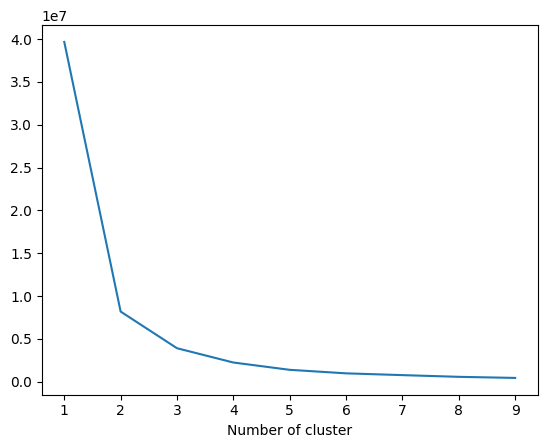

In [20]:
from sklearn.cluster import KMeans

sse={}
df_recency = df_user[['Recency']]

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(df_recency)
    df_recency["clusters"] = kmeans.labels_
    sse[k] = kmeans.inertia_ 
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_user[['Recency']])
df_user['RecencyCluster'] = kmeans.predict(df_user[['Recency']])

#function for ordering cluster numbers
def order_cluster(cluster_field_name, target_field_name,df,ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

df_user = order_cluster('RecencyCluster', 'Recency',df_user,False)
df_user.head()

,CustomerID,Recency,RecencyCluster
0,17850.0,301,0
1,15100.0,329,0
2,18074.0,373,0
3,16250.0,260,0
4,13747.0,373,0


In [22]:
#get order counts for each user and create a dataframe with it
df_frequency = df_uk.groupby('CustomerID').InvoiceDate.count().reset_index()
df_frequency.columns = ['CustomerID','Frequency']

#add this data to our main dataframe
df_user = pd.merge(df_user, df_frequency, on='CustomerID')

In [23]:
plot_data = [
    go.Histogram(
        x=df_user.query('Frequency < 1000')['Frequency']
    )
]

plot_layout = go.Layout(
        title='Frequency'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [24]:
#k-means
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_user[['Frequency']])
df_user['FrequencyCluster'] = kmeans.predict(df_user[['Frequency']])
print(df_user.head())
#order the frequency cluster

df_user = order_cluster('FrequencyCluster', 'Frequency',df_user,True)

#see details of each cluster
df_user.groupby('FrequencyCluster')['Frequency'].describe()

   CustomerID  Recency  RecencyCluster  Frequency  FrequencyCluster
0     17850.0      301               0        312                 2
1     15100.0      329               0          6                 0
2     18074.0      373               0         13                 0
3     16250.0      260               0         24                 0
4     13747.0      373               0          1                 0


,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,3496.0,49.525744,44.954212,1.0,15.0,33.0,73.0,190.0
1,429.0,331.221445,133.856510,191.0,228.0,287.0,399.0,803.0
2,22.0,1313.136364,505.934524,872.0,988.5,1140.0,1452.0,2782.0
3,3.0,5917.666667,1805.062418,4642.0,4885.0,5128.0,6555.5,7983.0


Insight: Pareto principle confirmed - Just 25 customers (0.6%) account for hyper-frequency (1,000+ purchases). These are likely B2B or reseller accounts requiring dedicated account management. The 3,496 "normal" customers with ~50 purchases/year represent the core retail segment.

In [25]:
#calculate revenue for each customer
df_uk['Revenue'] = df_uk['UnitPrice'] * df_uk['Quantity']
df_revenue = df_uk.groupby('CustomerID').Revenue.sum().reset_index()

#merge it with our main dataframe
df_user = pd.merge(df_user, df_revenue, on='CustomerID')

In [26]:
plot_data = [
    go.Histogram(
        x=df_user.query('Revenue < 10000')['Revenue']
    )
]

plot_layout = go.Layout(
        title='Monetary Value'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [27]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_user[['Revenue']])
df_user['RevenueCluster'] = kmeans.predict(df_user[['Revenue']])


#order the cluster numbers
df_user = order_cluster('RevenueCluster', 'Revenue',df_user,True)

#show details of the dataframe
df_user.groupby('RevenueCluster')['Revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
RevenueCluster,,,,,,,,
0,3785.0,1015.139695,1127.458066,-4287.63,270.6000,596.10,1349.5200,5845.44
1,144.0,10680.560208,5434.836870,5893.32,6851.1925,8658.97,11892.2775,29072.10
2,19.0,49665.701053,14544.232148,31300.08,35078.5550,50992.61,57253.3950,88125.38
3,2.0,221960.330000,48759.481478,187482.17,204721.2500,221960.33,239199.4100,256438.49


Insight: Revenue concentration is extreme - 2 customers generate £444K (avg £222K each), representing whale accounts. The 234 "mid-value" customers (avg £7.7K) are the sweet spot for growth - still engaged but with expansion potential. Focus account-based marketing on this tier.

In [29]:
#calculate overall score and use mean() to see details
df_user['OverallScore'] = df_user['RecencyCluster'] + df_user['FrequencyCluster'] + df_user['RevenueCluster']
df_user.groupby('OverallScore')[['Recency','Frequency','Revenue']].mean()

,Recency,Frequency,Revenue
OverallScore,,,
0,304.480000,22.065263,312.099200
1,185.403197,33.147425,508.728776
2,78.634783,46.789130,866.445600
3,20.585556,69.792453,1157.532564
4,13.879518,291.731928,3907.014910
5,8.926316,443.684211,11832.813474
6,5.684211,937.473684,26813.723684
7,1.857143,1784.285714,104112.257143
8,2.000000,6555.500000,48730.845000


In [30]:
df_user['Segment'] = 'Low-Value'
df_user.loc[df_user['OverallScore']>2,'Segment'] = 'Mid-Value' 
df_user.loc[df_user['OverallScore']>4,'Segment'] = 'High-Value' 

In [31]:
df_graph = df_user.query("Revenue < 50000 and Frequency < 2000")

In [32]:
plot_data = [
    go.Scatter(
        x=df_graph.query("Segment == 'Low-Value'")['Frequency'],
        y=df_graph.query("Segment == 'Low-Value'")['Revenue'],
        mode='markers',
        name='Low',
        marker= dict(size= 7,
            line= dict(width=1),
            color= 'blue',
            opacity= 0.8
           )
    ),
        go.Scatter(
        x=df_graph.query("Segment == 'Mid-Value'")['Frequency'],
        y=df_graph.query("Segment == 'Mid-Value'")['Revenue'],
        mode='markers',
        name='Mid',
        marker= dict(size= 9,
            line= dict(width=1),
            color= 'green',
            opacity= 0.5
           )
    ),
        go.Scatter(
        x=df_graph.query("Segment == 'High-Value'")['Frequency'],
        y=df_graph.query("Segment == 'High-Value'")['Revenue'],
        mode='markers',
        name='High',
        marker= dict(size= 11,
            line= dict(width=1),
            color= 'red',
            opacity= 0.9
           )
    ),
]

plot_layout = go.Layout(
        yaxis= {'title': "Revenue"},
        xaxis= {'title': "Frequency"},
        title='Segments'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

In [33]:
df_graph = df_user.query("Revenue < 50000 and Frequency < 2000")


In [34]:
plot_data = [
    go.Scatter(
        x=df_graph.query("Segment == 'Low-Value'")['Recency'],
        y=df_graph.query("Segment == 'Low-Value'")['Revenue'],
        mode='markers',
        name='Low',
        marker= dict(size= 7,
            line= dict(width=1),
            color= 'blue',
            opacity= 0.8
           )
    ),
        go.Scatter(
        x=df_graph.query("Segment == 'Mid-Value'")['Recency'],
        y=df_graph.query("Segment == 'Mid-Value'")['Revenue'],
        mode='markers',
        name='Mid',
        marker= dict(size= 9,
            line= dict(width=1),
            color= 'green',
            opacity= 0.5
           )
    ),
        go.Scatter(
        x=df_graph.query("Segment == 'High-Value'")['Recency'],
        y=df_graph.query("Segment == 'High-Value'")['Revenue'],
        mode='markers',
        name='High',
        marker= dict(size= 11,
            line= dict(width=1),
            color= 'red',
            opacity= 0.9
           )
    ),
]

plot_layout = go.Layout(
        yaxis= {'title': "Revenue"},
        xaxis= {'title': "Recency"},
        title='Segments'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

Insight: The scoring system effectively separates customer value. Score 0 customers (dormant, low-value) need win-back campaigns or should be deprioritized. Score 6+ customers are VIPs requiring white-glove service. The actionable sweet spot is scores 3-5 where small interventions can drive customers toward higher tiers.

In [35]:
df_graph = df_user.query("Revenue < 50000 and Frequency < 2000")


In [36]:
plot_data = [
    go.Scatter(
        x=df_graph.query("Segment == 'Low-Value'")['Recency'],
        y=df_graph.query("Segment == 'Low-Value'")['Frequency'],
        mode='markers',
        name='Low',
        marker= dict(size= 7,
            line= dict(width=1),
            color= 'blue',
            opacity= 0.8
           )
    ),
        go.Scatter(
        x=df_graph.query("Segment == 'Mid-Value'")['Recency'],
        y=df_graph.query("Segment == 'Mid-Value'")['Frequency'],
        mode='markers',
        name='Mid',
        marker= dict(size= 9,
            line= dict(width=1),
            color= 'green',
            opacity= 0.5
           )
    ),
        go.Scatter(
        x=df_graph.query("Segment == 'High-Value'")['Recency'],
        y=df_graph.query("Segment == 'High-Value'")['Frequency'],
        mode='markers',
        name='High',
        marker= dict(size= 11,
            line= dict(width=1),
            color= 'red',
            opacity= 0.9
           )
    ),
]

plot_layout = go.Layout(
        yaxis= {'title': "Frequency"},
        xaxis= {'title': "Recency"},
        title='Segments'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
fig.show()

Final Segment Distribution
Low-Value: Score 0-2
Mid-Value: Score 3-4
High-Value: Score 5+
Insight: This three-tier approach enables differentiated marketing strategies. High-value customers warrant personal outreach and exclusive offers. Mid-value should receive automated nurture sequences. Low-value can be targeted with aggressive discounts to prevent churn or reactivate.

### Enhanced Customer Segmentation: 4 Segments (Champions, Loyal, At Risk, Lost)

In [37]:
# Create 4 meaningful customer segments based on RFM scores
# Champions: Recent, frequent, high spenders (best customers)
# Loyal: Regular customers with good engagement
# At Risk: Were good customers but haven't purchased recently
# Lost: Haven't purchased in a long time, low engagement

def assign_segment(row):
    recency = row['Recency']
    frequency = row['Frequency']
    revenue = row['Revenue']
    score = row['OverallScore']
    
    # Champions: Low recency (recent), high frequency, high revenue
    if recency <= 30 and frequency >= 100 and revenue >= 2000:
        return 'Champions'
    # Champions also if overall score is very high
    elif score >= 6:
        return 'Champions'
    # At Risk: High recency (not recent) but were previously good customers
    elif recency > 90 and (frequency >= 50 or revenue >= 1000):
        return 'At Risk'
    # Lost: High recency, low frequency, low revenue
    elif recency > 120 and frequency < 50 and revenue < 1000:
        return 'Lost'
    # Loyal: Everything else with decent engagement
    else:
        return 'Loyal'

df_user['CustomerSegment'] = df_user.apply(assign_segment, axis=1)

# Calculate segment statistics
segment_stats = df_user.groupby('CustomerSegment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Revenue': 'mean'
}).round(2)
segment_stats.columns = ['Count', 'Avg Recency', 'Avg Frequency', 'Avg Revenue']
segment_stats['Percentage'] = (segment_stats['Count'] / segment_stats['Count'].sum() * 100).round(1)
segment_stats = segment_stats[['Count', 'Percentage', 'Avg Recency', 'Avg Frequency', 'Avg Revenue']]
print("Customer Segment Distribution:")
print(segment_stats)

Customer Segment Distribution:
                 Count  Percentage  Avg Recency  Avg Frequency  Avg Revenue
CustomerSegment                                                            
At Risk            302         7.6       177.85          85.14      1382.17
Champions          469        11.9         9.20         361.11      7934.03
Lost               891        22.6       239.30          17.09       273.64
Loyal             2288        57.9        38.17          66.25      1042.65


In [38]:
# 3D Scatter Plot: Recency vs Frequency vs Monetary Value
# Color by customer segment

# Filter for visualization (remove extreme outliers)
df_viz = df_user.query("Revenue < 50000 and Frequency < 2000").copy()

# Define colors and order for segments
segment_colors = {
    'Champions': '#2E7D32',  # Dark green
    'Loyal': '#1976D2',      # Blue
    'At Risk': '#F57C00',    # Orange
    'Lost': '#C62828'        # Red
}

segment_order = ['Champions', 'Loyal', 'At Risk', 'Lost']

# Calculate percentages for legend
segment_pcts = df_user['CustomerSegment'].value_counts(normalize=True) * 100

# Create 3D scatter plot
fig = go.Figure()

for segment in segment_order:
    df_seg = df_viz[df_viz['CustomerSegment'] == segment]
    pct = segment_pcts.get(segment, 0)
    
    fig.add_trace(go.Scatter3d(
        x=df_seg['Recency'],
        y=df_seg['Frequency'],
        z=df_seg['Revenue'],
        mode='markers',
        name=f'{segment} ({pct:.1f}%)',
        marker=dict(
            size=5,
            color=segment_colors[segment],
            opacity=0.7,
            line=dict(width=0.5, color='white')
        ),
        text=df_seg.apply(lambda r: f"R:{r['Recency']} F:{r['Frequency']:.0f} M:£{r['Revenue']:.0f}", axis=1),
        hoverinfo='text+name'
    ))

fig.update_layout(
    title=dict(
        text='<b>3D Customer Segmentation (RFM Analysis)</b><br><sup>Champions (top-right-front) vs Lost (bottom-left-back)</sup>',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Recency (days since last purchase)',
        yaxis_title='Frequency (number of purchases)',
        zaxis_title='Monetary Value (£)',
        xaxis=dict(autorange='reversed'),  # Lower recency = better, so reverse
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255,255,255,0.8)'
    ),
    width=900,
    height=700
)

fig.show()

print("\n📊 3D Plot Interpretation:")
print("• Champions (Green): Low Recency, High Frequency, High Revenue - your best customers!")
print("• Loyal (Blue): Regular engagement across RFM dimensions")
print("• At Risk (Orange): Were valuable but recency is increasing - need re-engagement")
print("• Lost (Red): High Recency, Low Frequency, Low Revenue - win-back or deprioritize")


📊 3D Plot Interpretation:
• Champions (Green): Low Recency, High Frequency, High Revenue - your best customers!
• Loyal (Blue): Regular engagement across RFM dimensions
• At Risk (Orange): Were valuable but recency is increasing - need re-engagement
• Lost (Red): High Recency, Low Frequency, Low Revenue - win-back or deprioritize


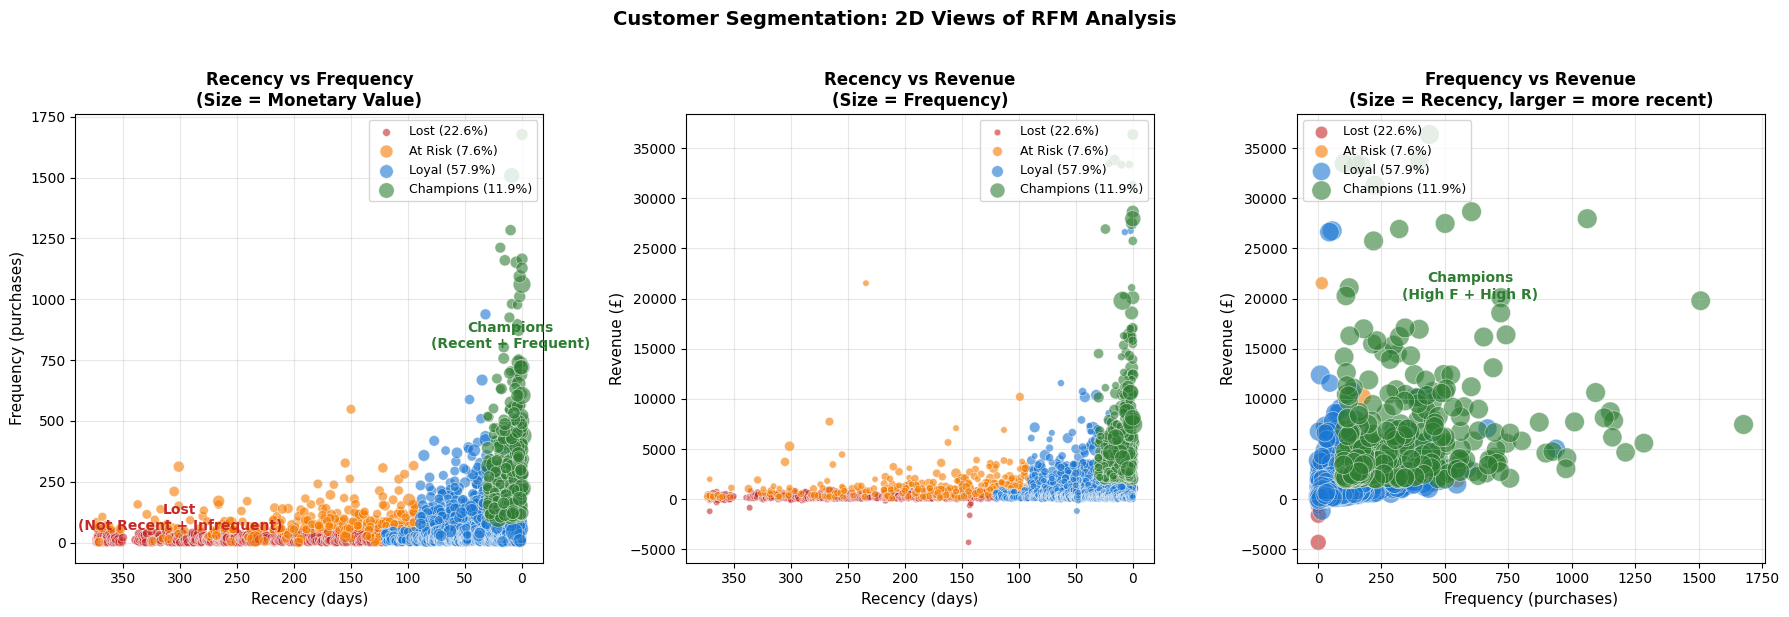


📈 2D Scatter Plot Insights:
• Plot 1 (R vs F): Champions cluster at low recency + high frequency
• Plot 2 (R vs M): Revenue correlates strongly with recent activity
• Plot 3 (F vs M): Clear positive correlation - frequent buyers spend more


In [39]:
# Multiple 2D Scatter Plots with clear segment visualization
# Size represents Monetary Value

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Color mapping
colors = {'Champions': '#2E7D32', 'Loyal': '#1976D2', 'At Risk': '#F57C00', 'Lost': '#C62828'}
segment_order = ['Lost', 'At Risk', 'Loyal', 'Champions']  # Plot order (Champions on top)

# Calculate percentages for legend
segment_pcts = df_user['CustomerSegment'].value_counts(normalize=True) * 100

# Normalize revenue for marker size (between 20 and 200)
df_viz['MarkerSize'] = 20 + (df_viz['Revenue'] - df_viz['Revenue'].min()) / (df_viz['Revenue'].max() - df_viz['Revenue'].min()) * 180

# Plot 1: Recency vs Frequency (size = Monetary)
ax1 = axes[0]
for segment in segment_order:
    df_seg = df_viz[df_viz['CustomerSegment'] == segment]
    pct = segment_pcts.get(segment, 0)
    ax1.scatter(df_seg['Recency'], df_seg['Frequency'], 
                s=df_seg['MarkerSize'], c=colors[segment], 
                label=f'{segment} ({pct:.1f}%)', alpha=0.6, edgecolors='white', linewidth=0.5)
ax1.set_xlabel('Recency (days)', fontsize=11)
ax1.set_ylabel('Frequency (purchases)', fontsize=11)
ax1.set_title('Recency vs Frequency\n(Size = Monetary Value)', fontsize=12, fontweight='bold')
ax1.invert_xaxis()  # Lower recency is better
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add annotations
ax1.annotate('Champions\n(Recent + Frequent)', xy=(10, 800), fontsize=10, 
             color='#2E7D32', fontweight='bold', ha='center')
ax1.annotate('Lost\n(Not Recent + Infrequent)', xy=(300, 50), fontsize=10, 
             color='#C62828', fontweight='bold', ha='center')

# Plot 2: Recency vs Revenue (size = Frequency)
ax2 = axes[1]
df_viz['FreqSize'] = 20 + (df_viz['Frequency'] - df_viz['Frequency'].min()) / (df_viz['Frequency'].max() - df_viz['Frequency'].min()) * 180
for segment in segment_order:
    df_seg = df_viz[df_viz['CustomerSegment'] == segment]
    pct = segment_pcts.get(segment, 0)
    ax2.scatter(df_seg['Recency'], df_seg['Revenue'], 
                s=df_seg['FreqSize'], c=colors[segment], 
                label=f'{segment} ({pct:.1f}%)', alpha=0.6, edgecolors='white', linewidth=0.5)
ax2.set_xlabel('Recency (days)', fontsize=11)
ax2.set_ylabel('Revenue (£)', fontsize=11)
ax2.set_title('Recency vs Revenue\n(Size = Frequency)', fontsize=12, fontweight='bold')
ax2.invert_xaxis()
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Frequency vs Revenue (size = Recency inverted)
ax3 = axes[2]
max_recency = df_viz['Recency'].max()
df_viz['RecencySize'] = 20 + (max_recency - df_viz['Recency']) / max_recency * 180  # Invert so recent = bigger
for segment in segment_order:
    df_seg = df_viz[df_viz['CustomerSegment'] == segment]
    pct = segment_pcts.get(segment, 0)
    ax3.scatter(df_seg['Frequency'], df_seg['Revenue'], 
                s=df_seg['RecencySize'], c=colors[segment], 
                label=f'{segment} ({pct:.1f}%)', alpha=0.6, edgecolors='white', linewidth=0.5)
ax3.set_xlabel('Frequency (purchases)', fontsize=11)
ax3.set_ylabel('Revenue (£)', fontsize=11)
ax3.set_title('Frequency vs Revenue\n(Size = Recency, larger = more recent)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# Add annotations
ax3.annotate('Champions\n(High F + High R)', xy=(600, 20000), fontsize=10, 
             color='#2E7D32', fontweight='bold', ha='center')

plt.suptitle('Customer Segmentation: 2D Views of RFM Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('customer_segments_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 2D Scatter Plot Insights:")
print("• Plot 1 (R vs F): Champions cluster at low recency + high frequency")
print("• Plot 2 (R vs M): Revenue correlates strongly with recent activity")
print("• Plot 3 (F vs M): Clear positive correlation - frequent buyers spend more")

### Power Law Analysis: Customer vs Revenue Distribution

In [40]:
# Calculate customer % and revenue % by segment
segment_analysis = df_user.groupby('CustomerSegment').agg({
    'CustomerID': 'count',
    'Revenue': 'sum'
}).reset_index()

segment_analysis.columns = ['Segment', 'CustomerCount', 'TotalRevenue']
segment_analysis['Customer%'] = (segment_analysis['CustomerCount'] / segment_analysis['CustomerCount'].sum() * 100)
segment_analysis['Revenue%'] = (segment_analysis['TotalRevenue'] / segment_analysis['TotalRevenue'].sum() * 100)

# Order by value (Champions first)
segment_order = ['Champions', 'Loyal', 'At Risk', 'Lost']
segment_analysis['Segment'] = pd.Categorical(segment_analysis['Segment'], categories=segment_order, ordered=True)
segment_analysis = segment_analysis.sort_values('Segment')

print("Segment Analysis:")
print(segment_analysis[['Segment', 'CustomerCount', 'Customer%', 'TotalRevenue', 'Revenue%']].round(1).to_string(index=False))

# Colors matching the scatter plots
colors = {'Champions': '#2E7D32', 'Loyal': '#1976D2', 'At Risk': '#F57C00', 'Lost': '#C62828'}

Segment Analysis:
  Segment  CustomerCount  Customer%  TotalRevenue  Revenue%
Champions            469       11.9     3721057.8      55.0
    Loyal           2288       57.9     2385589.1      35.2
  At Risk            302        7.6      417414.3       6.2
     Lost            891       22.6      243812.2       3.6


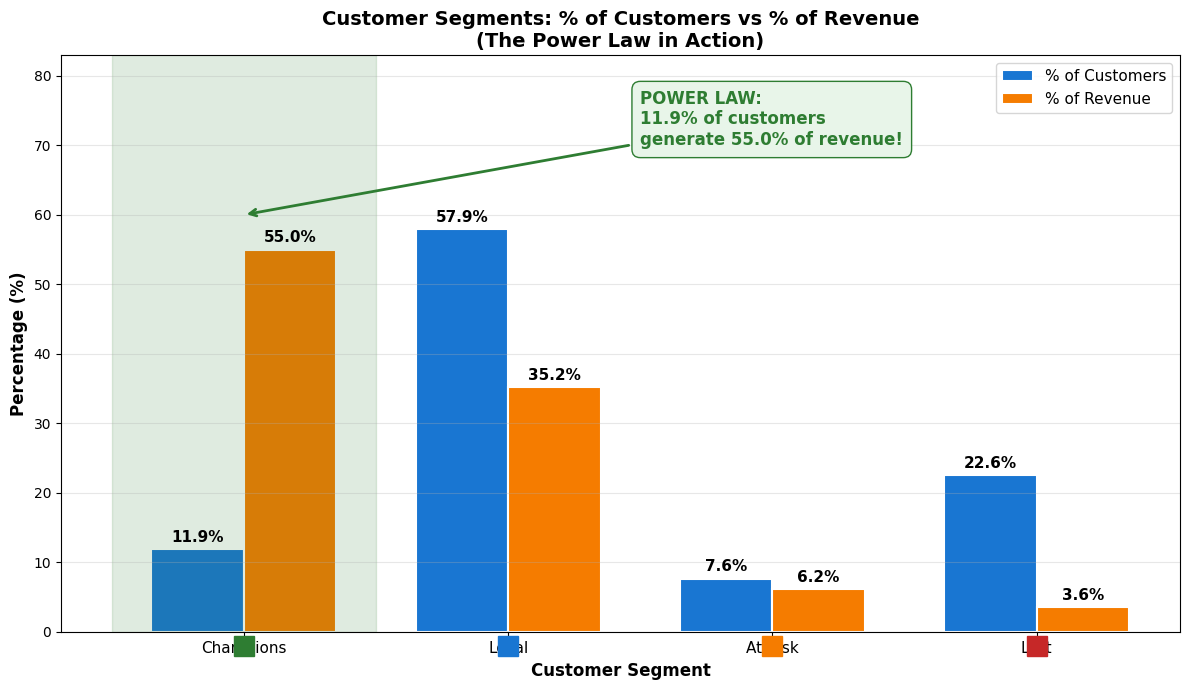

In [41]:
# VERSION A: Grouped Bar Chart - Side by side comparison
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(segment_analysis))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, segment_analysis['Customer%'], width, 
               label='% of Customers', color='#1976D2', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, segment_analysis['Revenue%'], width, 
               label='% of Revenue', color='#F57C00', edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

# Highlight Champions segment
champion_idx = list(segment_analysis['Segment']).index('Champions')
ax.axvspan(champion_idx - 0.5, champion_idx + 0.5, alpha=0.15, color='#2E7D32')

# Get actual values for Champions
champ_cust = segment_analysis[segment_analysis['Segment'] == 'Champions']['Customer%'].values[0]
champ_rev = segment_analysis[segment_analysis['Segment'] == 'Champions']['Revenue%'].values[0]

# Add power law annotation
ax.annotate(f'POWER LAW:\n{champ_cust:.1f}% of customers\ngenerate {champ_rev:.1f}% of revenue!',
            xy=(champion_idx, max(champ_cust, champ_rev) + 5),
            xytext=(champion_idx + 1.5, max(champ_cust, champ_rev) + 15),
            fontsize=12, fontweight='bold', color='#2E7D32',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9', edgecolor='#2E7D32'),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Styling
ax.set_xlabel('Customer Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Customer Segments: % of Customers vs % of Revenue\n(The Power Law in Action)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(segment_analysis['Segment'], fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, max(segment_analysis['Customer%'].max(), segment_analysis['Revenue%'].max()) + 25)
ax.grid(True, alpha=0.3, axis='y')

# Add segment color indicators
for i, segment in enumerate(segment_analysis['Segment']):
    ax.plot(i, -2, 's', markersize=15, color=colors[segment], clip_on=False)

plt.tight_layout()
plt.savefig('segment_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

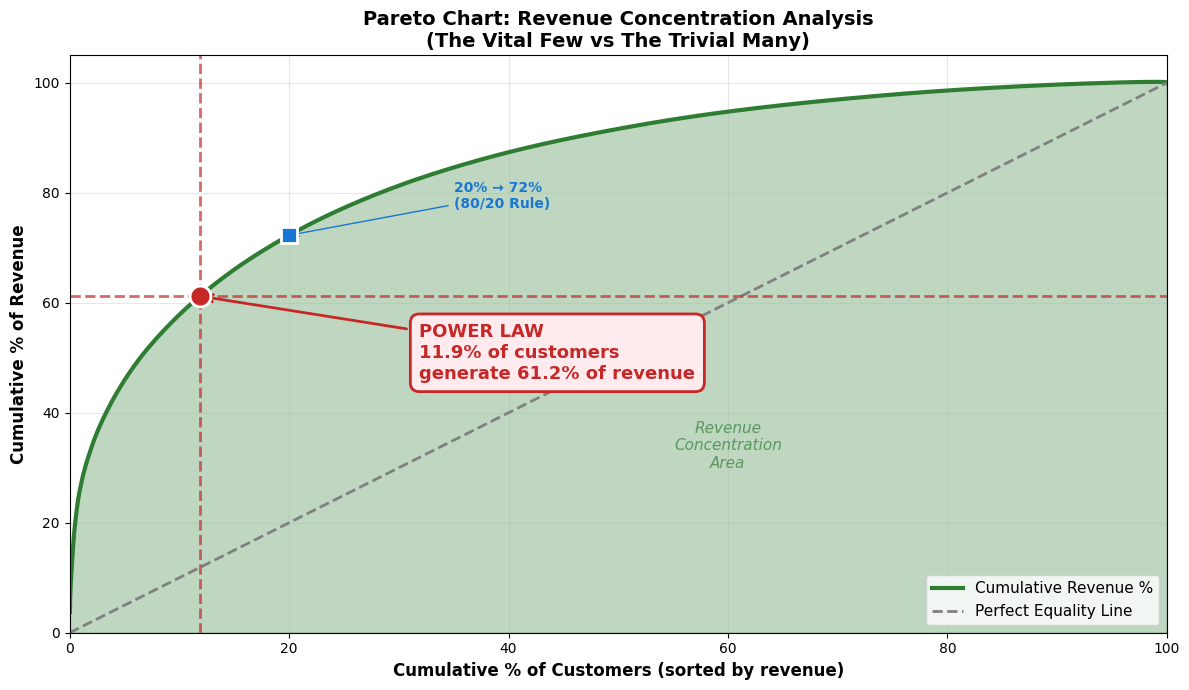


📊 Pareto Analysis Results:
• Top 11.9% of customers (Champions) generate 61.2% of revenue
• Top 20% of customers generate 72% of revenue
• This confirms the Power Law / Pareto Principle in customer value distribution


In [42]:
# VERSION B: Pareto Chart - Cumulative % of customers vs % of revenue
# Sort customers by revenue (highest first)
df_pareto = df_user[['CustomerID', 'Revenue']].sort_values('Revenue', ascending=False).reset_index(drop=True)
df_pareto['CumulativeRevenue'] = df_pareto['Revenue'].cumsum()
df_pareto['CumulativeRevenue%'] = df_pareto['CumulativeRevenue'] / df_pareto['Revenue'].sum() * 100
df_pareto['Customer%'] = (df_pareto.index + 1) / len(df_pareto) * 100

fig, ax = plt.subplots(figsize=(12, 7))

# Plot the Pareto curve
ax.fill_between(df_pareto['Customer%'], df_pareto['CumulativeRevenue%'], 
                alpha=0.3, color='#2E7D32')
ax.plot(df_pareto['Customer%'], df_pareto['CumulativeRevenue%'], 
        linewidth=3, color='#2E7D32', label='Cumulative Revenue %')

# Add diagonal line (perfect equality)
ax.plot([0, 100], [0, 100], '--', color='gray', linewidth=2, label='Perfect Equality Line')

# Find the key point (where Champions end - approximately 11.5% of customers)
champ_pct = segment_analysis[segment_analysis['Segment'] == 'Champions']['Customer%'].values[0]
champ_rev_pct = segment_analysis[segment_analysis['Segment'] == 'Champions']['Revenue%'].values[0]

# Find closest point in pareto data
closest_idx = (df_pareto['Customer%'] - champ_pct).abs().idxmin()
actual_rev_at_champ = df_pareto.loc[closest_idx, 'CumulativeRevenue%']

# Add vertical and horizontal lines for Champions
ax.axvline(x=champ_pct, color='#C62828', linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(y=actual_rev_at_champ, color='#C62828', linestyle='--', linewidth=2, alpha=0.7)

# Mark the intersection point
ax.plot(champ_pct, actual_rev_at_champ, 'o', markersize=15, color='#C62828', 
        markeredgecolor='white', markeredgewidth=2, zorder=5)

# Add annotation box
ax.annotate(f'POWER LAW\n{champ_pct:.1f}% of customers\ngenerate {actual_rev_at_champ:.1f}% of revenue',
            xy=(champ_pct, actual_rev_at_champ),
            xytext=(champ_pct + 20, actual_rev_at_champ - 15),
            fontsize=13, fontweight='bold', color='#C62828',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFEBEE', edgecolor='#C62828', linewidth=2),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2))

# Add 80/20 reference point
idx_20 = (df_pareto['Customer%'] - 20).abs().idxmin()
rev_at_20 = df_pareto.loc[idx_20, 'CumulativeRevenue%']
ax.plot(20, rev_at_20, 's', markersize=12, color='#1976D2', 
        markeredgecolor='white', markeredgewidth=2, zorder=5)
ax.annotate(f'20% → {rev_at_20:.0f}%\n(80/20 Rule)', 
            xy=(20, rev_at_20), xytext=(35, rev_at_20 + 5),
            fontsize=10, fontweight='bold', color='#1976D2',
            arrowprops=dict(arrowstyle='->', color='#1976D2'))

# Styling
ax.set_xlabel('Cumulative % of Customers (sorted by revenue)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative % of Revenue', fontsize=12, fontweight='bold')
ax.set_title('Pareto Chart: Revenue Concentration Analysis\n(The Vital Few vs The Trivial Many)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Add Gini-like shaded area label
ax.text(60, 30, 'Revenue\nConcentration\nArea', fontsize=11, ha='center', 
        color='#2E7D32', fontstyle='italic', alpha=0.7)

plt.tight_layout()
plt.savefig('pareto_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Pareto Analysis Results:")
print(f"• Top {champ_pct:.1f}% of customers (Champions) generate {actual_rev_at_champ:.1f}% of revenue")
print(f"• Top 20% of customers generate {rev_at_20:.0f}% of revenue")
print(f"• This confirms the Power Law / Pareto Principle in customer value distribution")